# Week 4: Fine Tuning ViT

(see summary at the bottom and notes throughout)

**general set up and libraries**

same thing as previous weeks. See week 2 for library explanation.

In [1]:
from google.colab import drive
drive.mount('/content/drive')
!unzip -q -o /content/drive/MyDrive/deepfake_capstone/frames.zip -d /content/

Mounted at /content/drive
A


In [2]:
import torch
print(f"GPU: {torch.cuda.get_device_name(0)}")

GPU: NVIDIA A100-SXM4-40GB


In [3]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
from torchvision.transforms import RandAugment
import timm
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import (classification_report, confusion_matrix,
                             roc_auc_score, ConfusionMatrixDisplay)
from tqdm import tqdm
import os, copy, json

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using: {device}")

Using: cuda


# Data Set Up

Goal for this week is to hit the overfitting as hard as possible and fine tune the model.

The train transform we see here is everything that is being done to the training data. We have: horizontal flip, rotation is now + - 15 degrees now, some grayscale, perspective distortions. This is to make the first part of the effort to nail in generalization and tamper the overfitting away. RandAugment is the most advanced one that is being used, it will take a random number of augmentation operations and applies them to certain magnitudes. Val is the same as previous weeks and so is the dataset designations. The class weights we are inversing are being kept the same as previous weeks and we are keeping the workers to 4.





In [4]:
data_dir = '/content/frames'

# Stronger augmentation to fight overfitting
train_transform = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.2),
    transforms.RandomGrayscale(p=0.05),
    transforms.RandomPerspective(distortion_scale=0.1, p=0.3),
    RandAugment(num_ops=2, magnitude=9),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

val_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

train_dataset = datasets.ImageFolder(os.path.join(data_dir, 'train'), transform=train_transform)
val_dataset = datasets.ImageFolder(os.path.join(data_dir, 'val'), transform=val_transform)
test_dataset = datasets.ImageFolder(os.path.join(data_dir, 'test'), transform=val_transform)

print(f"Classes: {train_dataset.classes}")
print(f"Class mapping: {train_dataset.class_to_idx}")
print(f"Train: {len(train_dataset)}, Val: {len(val_dataset)}, Test: {len(test_dataset)}")

Classes: ['fake', 'real']
Class mapping: {'fake': 0, 'real': 1}
Train: 195786, Val: 34636, Test: 20055


In [5]:
train_targets = [s[1] for s in train_dataset.samples]
class_counts = np.bincount(train_targets)
print(f"Class counts - fake: {class_counts[0]}, real: {class_counts[1]}")

class_weights = 1.0 / class_counts
sample_weights = [class_weights[t] for t in train_targets]
sampler = torch.utils.data.WeightedRandomSampler(sample_weights, len(sample_weights))

BATCH_SIZE = 64

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, sampler=sampler, num_workers=4)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=4)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=4)

print(f"Batches per epoch - Train: {len(train_loader)}, Val: {len(val_loader)}, Test: {len(test_loader)}")

Class counts - fake: 170930, real: 24856
Batches per epoch - Train: 3060, Val: 542, Test: 314


# Model Setup

Here biggest difference is that instead of the last 3 blocks being thawed it is the last 6, so that way more layers can be trained and pick up on the task we are trying to do. Everything else is the same as week 3.

**loss, optimizer, and scheduler**
Now lets try smoothing the labels to get rid of the models over confident predictions, which should help hit the overfitting. Label smoothing is a regularization technique, instead of static, hard labels like 0 or 1, it softens them by adding a lil uniform distribution.

Everything else is the same from week 3


In [6]:
# Load pretrained ViT-Base/16
model = timm.create_model('vit_base_patch16_224', pretrained=True, num_classes=2)

# Freeze everything
for param in model.parameters():
    param.requires_grad = False

# Thaw classifier head
for param in model.head.parameters():
    param.requires_grad = True

# Thaw layer norm
for param in model.norm.parameters():
    param.requires_grad = True

# Thaw last 6 blocks instead of 3
for param in model.blocks[-6:].parameters():
    param.requires_grad = True

model = model.to(device)

trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
total = sum(p.numel() for p in model.parameters())
print(f"Trainable params: {trainable:,} / {total:,} ({100*trainable/total:.1f}%)")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


model.safetensors:   0%|          | 0.00/346M [00:00<?, ?B/s]

Trainable params: 42,530,306 / 85,800,194 (49.6%)


In [7]:
# Weighted loss WITH label smoothing to reduce overconfidence
weight_tensor = torch.tensor([1.0, class_counts[0]/class_counts[1]], dtype=torch.float).to(device)
criterion = nn.CrossEntropyLoss(weight=weight_tensor, label_smoothing=0.1)
print(f"Loss weights - fake: {weight_tensor[0]:.2f}, real: {weight_tensor[1]:.2f}")
print("Label smoothing: 0.1")

optimizer = optim.AdamW(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=3e-5,
    weight_decay=0.01
)

NUM_EPOCHS = 15
warmup_epochs = 2
scheduler_cosine = optim.lr_scheduler.CosineAnnealingLR(
    optimizer, T_max=NUM_EPOCHS - warmup_epochs, eta_min=1e-6)
scheduler_warmup = optim.lr_scheduler.LinearLR(
    optimizer, start_factor=0.1, total_iters=warmup_epochs)
scheduler = optim.lr_scheduler.SequentialLR(
    optimizer, schedulers=[scheduler_warmup, scheduler_cosine], milestones=[warmup_epochs])

Loss weights - fake: 1.00, real: 6.88
Label smoothing: 0.1


# Training the Model

No scaler this time to see if that makes a difference since it does hurt accuracy. Nothing has changed from week 3

In [8]:
def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in tqdm(loader, desc="Training", leave=False):
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()

        running_loss += loss.item() * images.size(0)
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()

    return running_loss / total, correct / total


def evaluate(model, loader, criterion, device):
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0
    all_probs = []
    all_labels = []

    with torch.no_grad():
        for images, labels in tqdm(loader, desc="Evaluating", leave=False):
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)

            running_loss += loss.item() * images.size(0)
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()

            probs = torch.softmax(outputs, dim=1)[:, 1]
            all_probs.extend(probs.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    auc = roc_auc_score(all_labels, all_probs)
    return running_loss / total, correct / total, auc, all_probs, all_labels

In [9]:
best_val_auc = 0.0
best_model_state = None
patience_counter = 0
PATIENCE = 5
history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': [], 'val_auc': []}

for epoch in range(NUM_EPOCHS):
    train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer, device)
    val_loss, val_acc, val_auc, _, _ = evaluate(model, val_loader, criterion, device)
    scheduler.step()

    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    history['train_acc'].append(train_acc)
    history['val_acc'].append(val_acc)
    history['val_auc'].append(val_auc)

    current_lr = optimizer.param_groups[0]['lr']
    print(f"Epoch {epoch+1}/{NUM_EPOCHS} | "
          f"Train Loss: {train_loss:.4f} Acc: {train_acc:.4f} | "
          f"Val Loss: {val_loss:.4f} Acc: {val_acc:.4f} AUC: {val_auc:.4f} | "
          f"LR: {current_lr:.6f}")

    if val_auc > best_val_auc:
        best_val_auc = val_auc
        best_model_state = copy.deepcopy(model.state_dict())
        patience_counter = 0
        print(f"  -> New best model (AUC: {val_auc:.4f})")
    else:
        patience_counter += 1
        if patience_counter >= PATIENCE:
            print(f"  -> Early stopping at epoch {epoch+1}")
            break

# Save best model
model.load_state_dict(best_model_state)
save_path = '/content/drive/MyDrive/deepfake_capstone/checkpoints/'
os.makedirs(save_path, exist_ok=True)
torch.save(best_model_state, os.path.join(save_path, 'vit_base16_v2_best.pth'))
print(f"\nBest model saved with Val AUC: {best_val_auc:.4f}")

Epoch 1/15 | Train Loss: 0.2761 Acc: 0.6629 | Val Loss: 1.0365 Acc: 0.6290 AUC: 0.7919 | LR: 0.000017
  -> New best model (AUC: 0.7919)


Epoch 2/15 | Train Loss: 0.2270 Acc: 0.7916 | Val Loss: 0.8991 Acc: 0.7934 AUC: 0.7920 | LR: 0.000030
  -> New best model (AUC: 0.7920)


Epoch 3/15 | Train Loss: 0.2053 Acc: 0.8560 | Val Loss: 0.8965 Acc: 0.8320 AUC: 0.7658 | LR: 0.000030


Epoch 4/15 | Train Loss: 0.1892 Acc: 0.8905 | Val Loss: 0.9422 Acc: 0.7949 AUC: 0.7319 | LR: 0.000028


Epoch 5/15 | Train Loss: 0.1811 Acc: 0.9095 | Val Loss: 0.8899 Acc: 0.8430 AUC: 0.7338 | LR: 0.000026


Epoch 6/15 | Train Loss: 0.1748 Acc: 0.9219 | Val Loss: 0.8290 Acc: 0.8756 AUC: 0.7134 | LR: 0.000024


Epoch 7/15 | Train Loss: 0.1704 Acc: 0.9311 | Val Loss: 0.8916 Acc: 0.8443 AUC: 0.7645 | LR: 0.000021
  -> Early stopping at epoch 7

Best model saved with Val AUC: 0.7920


# Plots

Plot 1: 3 subplots comparing performance metrics across EN, ViT v1, and ViT v2

Plot 2: v2 test metrics, classification report, and confusion matrix

Comparisons: visual comparison chart of EN, v1, and v2; comprises of test AUC-ROC, test accuracy, and best AUC.

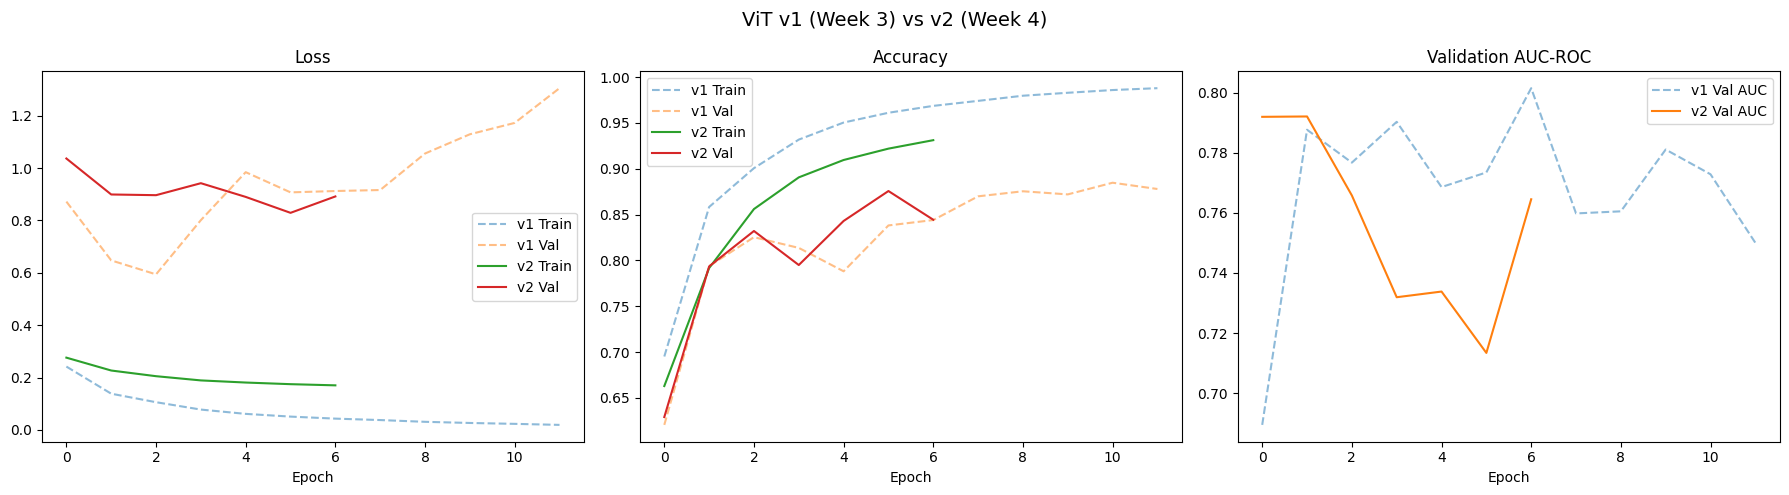

In [10]:
with open('/content/drive/MyDrive/deepfake_capstone/checkpoints/vit_v1_history.json', 'r') as f:
    history_v1 = json.load(f)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].plot(history_v1['train_loss'], '--', alpha=0.5, label='v1 Train')
axes[0].plot(history_v1['val_loss'], '--', alpha=0.5, label='v1 Val')
axes[0].plot(history['train_loss'], label='v2 Train')
axes[0].plot(history['val_loss'], label='v2 Val')
axes[0].set_title('Loss')
axes[0].set_xlabel('Epoch')
axes[0].legend()

axes[1].plot(history_v1['train_acc'], '--', alpha=0.5, label='v1 Train')
axes[1].plot(history_v1['val_acc'], '--', alpha=0.5, label='v1 Val')
axes[1].plot(history['train_acc'], label='v2 Train')
axes[1].plot(history['val_acc'], label='v2 Val')
axes[1].set_title('Accuracy')
axes[1].set_xlabel('Epoch')
axes[1].legend()

axes[2].plot(history_v1['val_auc'], '--', alpha=0.5, label='v1 Val AUC')
axes[2].plot(history['val_auc'], label='v2 Val AUC')
axes[2].set_title('Validation AUC-ROC')
axes[2].set_xlabel('Epoch')
axes[2].legend()

plt.suptitle('ViT v1 (Week 3) vs v2 (Week 4)', fontsize=14)
plt.tight_layout()
fig.savefig('/content/drive/MyDrive/deepfake_capstone/results/vit_v2_learning_curves.png', dpi=150)
plt.show()

Test Loss: 0.7992
Test Accuracy: 0.7622
Test AUC-ROC: 0.8325

Classification Report:
              precision    recall  f1-score   support

        fake       0.85      0.77      0.81     12939
        real       0.64      0.74      0.69      7116

    accuracy                           0.76     20055
   macro avg       0.74      0.76      0.75     20055
weighted avg       0.77      0.76      0.77     20055



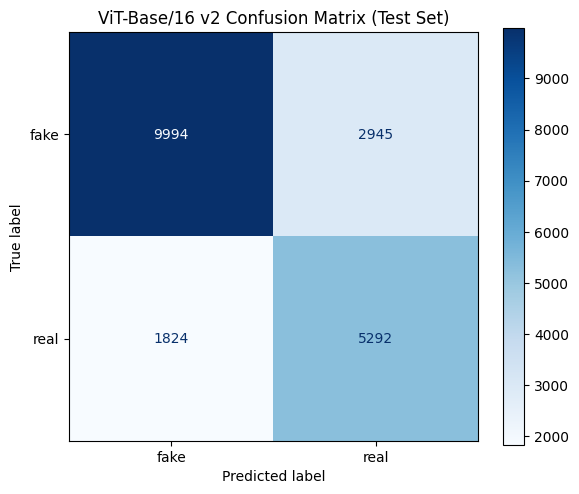

In [11]:
test_loss, test_acc, test_auc, test_probs, test_labels = evaluate(
    model, test_loader, criterion, device)

print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_acc:.4f}")
print(f"Test AUC-ROC: {test_auc:.4f}")

test_preds = [1 if p > 0.5 else 0 for p in test_probs]
print("\nClassification Report:")
print(classification_report(test_labels, test_preds, target_names=train_dataset.classes))

cm = confusion_matrix(test_labels, test_preds)
fig_cm, ax = plt.subplots(figsize=(6, 5))
disp = ConfusionMatrixDisplay(cm, display_labels=train_dataset.classes)
disp.plot(ax=ax, cmap='Blues')
ax.set_title('ViT-Base/16 v2 Confusion Matrix (Test Set)')
plt.tight_layout()
fig_cm.savefig('/content/drive/MyDrive/deepfake_capstone/results/vit_v2_confusion_matrix.png', dpi=150)
plt.show()

In [12]:
print("=" * 70)
print(f"{'Metric':<20} {'EfficientNet':>14} {'ViT v1':>14} {'ViT v2':>14}")
print("=" * 70)
print(f"{'Test AUC-ROC':<20} {'0.7706':>14} {'0.8137':>14} {test_auc:>14.4f}")
print(f"{'Test Accuracy':<20} {'73.93%':>14} {'75.77%':>14} {test_acc*100:>13.2f}%")
print(f"{'Best Val AUC':<20} {'0.7626':>14} {'0.8015':>14} {best_val_auc:>14.4f}")
print("=" * 70)

Metric                 EfficientNet         ViT v1         ViT v2
Test AUC-ROC                 0.7706         0.8137         0.8325
Test Accuracy                73.93%         75.77%         76.22%
Best Val AUC                 0.7626         0.8015         0.7920


In [13]:
# Save v2 history
history_save = {k: [float(v) for v in vals] for k, vals in history.items()}
with open('/content/drive/MyDrive/deepfake_capstone/checkpoints/vit_v2_history.json', 'w') as f:
    json.dump(history_save, f)

print("All Week 4 artifacts saved.")

All Week 4 artifacts saved.


# Summary

Iterated on the Week 3 ViT with three targeted changes to fight overfitting and improve real recall: stronger augmentation (RandAugment, random perspective, grayscale), label smoothing at 0.1 to reduce overconfident predictions, and thawing 6 transformer blocks instead of 3 for more learning capacity.

**Results**: 76.22% test accuracy, 0.8325 AUC-ROC was the  best model across all experiments. Real recall jumped to 74% (up from 52% at baseline), the biggest single improvement in the project. The tradeoff was fake recall dropping from 86% to 77%, but overall class-balanced performance improved with macro F1 going from 0.70 (baseline) to 0.75. The overfitting gap shrank significantly — train loss stayed around 0.17 vs v1's 0.02, confirming the augmentation worked. Early stopping kicked in at epoch 7.

**Takeaways**: The strongest gains came from making better use of existing data through regularization, not from more data or a bigger model. The improvement arc across all three models (EfficientNet → ViT v1 → ViT v2) shows that transformer attention + proper regularization outperforms CNNs at deepfake detection, with the biggest gains in the hardest and most vital part of the task correctly identifying real images.